In [1]:
%who

Interactive namespace is empty.


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("creditcard.csv")
print("Loaded:", df.shape)

Loaded: (284807, 31)


In [4]:
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (283726, 31)


In [5]:
X = df.drop("Class", axis=1)   # all columns EXCEPT Class = features
y = df["Class"]                # only Class = the answer (fraud or not)

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (283726, 30)
Target (y): (283726,)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done! Shape:", X_scaled.shape)

Scaling done! Shape: (283726, 30)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # reproducible results
    stratify=y            # keep fraud ratio in both sets
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (226980, 30)
Test set: (56746, 30)


In [8]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_balanced.shape)
print("\nFraud balance after SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE: (226980, 30)
After SMOTE: (453204, 30)

Fraud balance after SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it (this is where it LEARNS!)
print("Training... (this takes a minute)")
rf_model.fit(X_train_balanced, y_train_balanced)

print("✅ DONE! Your Random Forest is trained!")

Training... (this takes a minute)
✅ DONE! Your Random Forest is trained!


In [10]:
# Make predictions on the test set (data it has NEVER seen)
y_pred = rf_model.predict(X_test)

print("✅ Predictions made on", len(y_pred), "unseen transactions!")
print("\nFirst 20 predictions:", y_pred[:20])

✅ Predictions made on 56746 unseen transactions!

First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [11]:
# Count how many frauds the model predicted
import numpy as np
print("Total predictions:", len(y_pred))
print("Predicted LEGIT (0):", np.sum(y_pred == 0))
print("Predicted FRAUD (1):", np.sum(y_pred == 1))

Total predictions: 56746
Predicted LEGIT (0): 56669
Predicted FRAUD (1): 77


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

# The confusion matrix
print("CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred))

print("\nDETAILED REPORT:")
print(classification_report(y_test, y_pred))

CONFUSION MATRIX:
[[56644     7]
 [   25    70]]

DETAILED REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.74      0.81        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [13]:
from xgboost import XGBClassifier

# Create the model
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Train it (.fit = learn)
print("Training XGBoost...")
xgb_model.fit(X_train_balanced, y_train_balanced)

print("✅ XGBoost trained!")

Training XGBoost...
✅ XGBoost trained!


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on unseen test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBOOST CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nXGBOOST REPORT:")
print(classification_report(y_test, y_pred_xgb))

XGBOOST CONFUSION MATRIX:
[[56622    29]
 [   19    76]]

XGBOOST REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.80      0.76        95

    accuracy                           1.00     56746
   macro avg       0.86      0.90      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [15]:
from sklearn.neural_network import MLPClassifier

# Create the Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers: 64 and 32 neurons
    max_iter=300,                  # training rounds
    random_state=42
)

# Train it (.fit = learn via gradient descent)
print("Training Neural Network... (this takes a few minutes)")
nn_model.fit(X_train_balanced, y_train_balanced)

print("✅ Neural Network trained!")

Training Neural Network... (this takes a few minutes)
✅ Neural Network trained!


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on unseen test data
y_pred_nn = nn_model.predict(X_test)

# Evaluate
print("NEURAL NETWORK CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_nn))

print("\nNEURAL NETWORK REPORT:")
print(classification_report(y_test, y_pred_nn))

NEURAL NETWORK CONFUSION MATRIX:
[[56635    16]
 [   22    73]]

NEURAL NETWORK REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.77      0.79        95

    accuracy                           1.00     56746
   macro avg       0.91      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [17]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('nn', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))
]

hybrid_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

print("Hybrid model created! Ready to train.")

Hybrid model created! Ready to train.


In [18]:
print("Training the HYBRID model... (this takes several minutes)")
print("It's training RF + XGBoost + NN + the meta-model...")

hybrid_model.fit(X_train_balanced, y_train_balanced)

print("✅ HYBRID model trained!")

Training the HYBRID model... (this takes several minutes)
It's training RF + XGBoost + NN + the meta-model...
✅ HYBRID model trained!


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict with the hybrid
y_pred_hybrid = hybrid_model.predict(X_test)

# Evaluate
print("HYBRID CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred_hybrid))

print("\nHYBRID REPORT:")
print(classification_report(y_test, y_pred_hybrid))

HYBRID CONFUSION MATRIX:
[[56642     9]
 [   19    76]]

HYBRID REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.95      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [20]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [21]:
print("Checking what's loaded...")
try:
    print("X_test:", X_test.shape)
    print("xgb_model:", type(xgb_model).__name__)
    print("✅ Ready for SHAP!")
except NameError as e:
    print("❌ Need to reload:", e)

Checking what's loaded...
X_test: (56746, 30)
xgb_model: XGBClassifier
✅ Ready for SHAP!


In [22]:
import shap

# Create the SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values on a sample of test data (faster)
print("Calculating SHAP values... (takes a minute)")
X_sample = X_test[:1000]   # use 1000 transactions for speed
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")
print("Shape:", shap_values.shape)

Calculating SHAP values... (takes a minute)
✅ SHAP values calculated!
Shape: (1000, 30)


Creating SHAP summary plot...


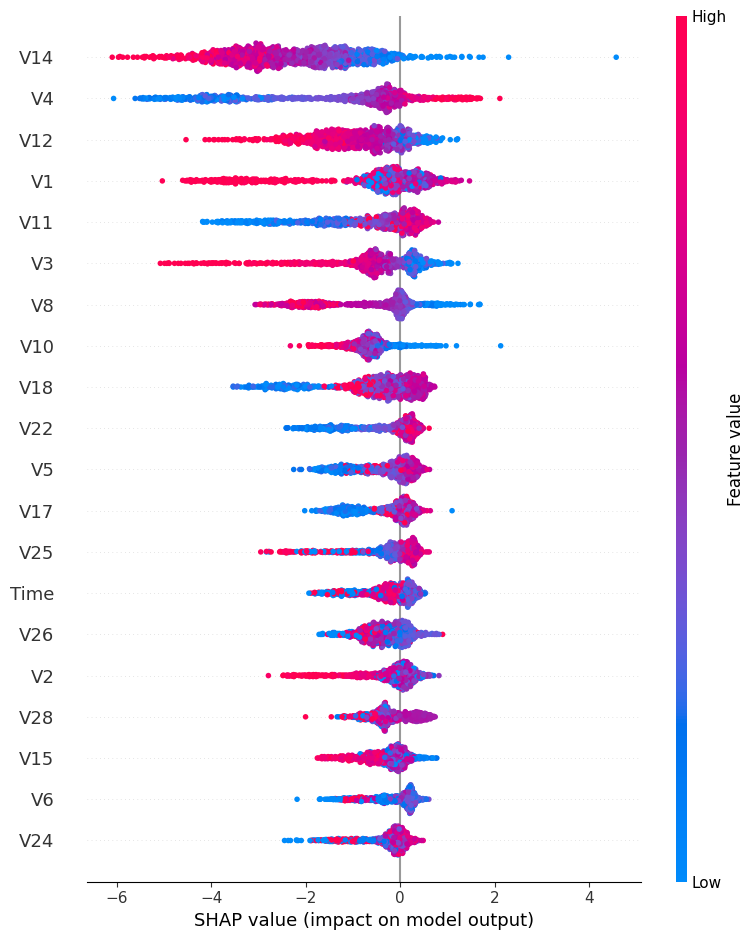

✅ Plot saved as shap_summary.png!


In [23]:
import matplotlib.pyplot as plt

# Get feature names
feature_names = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']

# Create the summary plot
print("Creating SHAP summary plot...")
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Plot saved as shap_summary.png!")

In [24]:
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

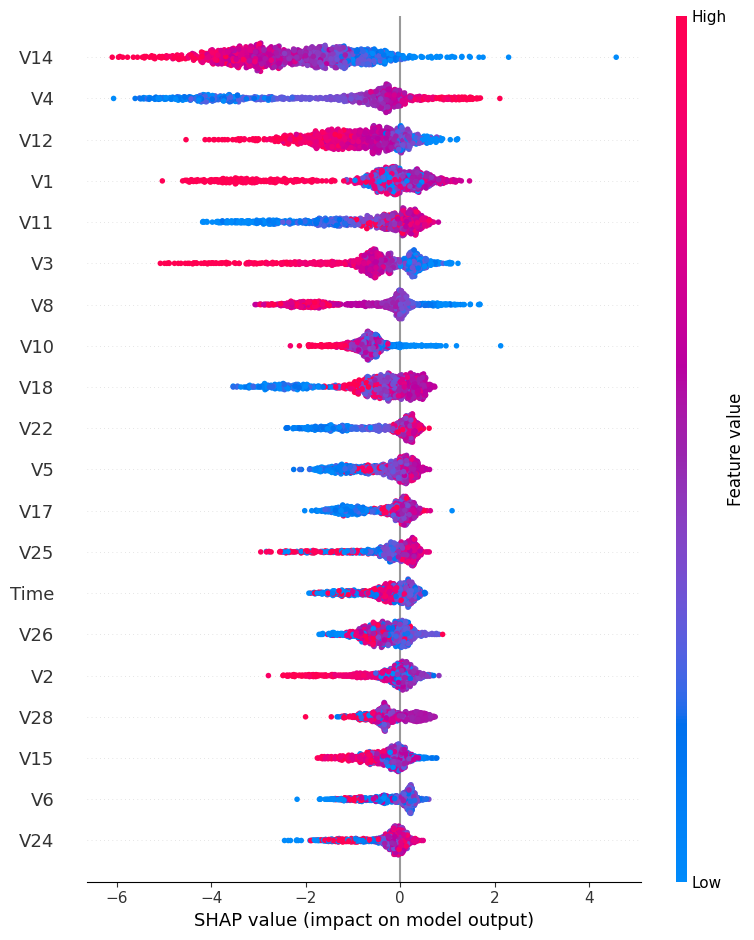

✅ Saved as shap_summary.png!


In [25]:
import matplotlib.pyplot as plt
import shap

# Create the summary plot fresh and save it
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved as shap_summary.png!")

In [26]:
# Explain ONE specific transaction (the first fraud-like one)
print("SHAP values let us explain individual predictions too!")
print("\nFor transaction 0:")
print("Top features pushing the decision:")

# Get feature contributions for transaction 0
import numpy as np
contributions = list(zip(feature_names, shap_values[0]))
contributions_sorted = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)

for feat, val in contributions_sorted[:5]:
    direction = "→ FRAUD" if val > 0 else "→ LEGIT"
    print(f"  {feat}: {val:.3f} {direction}")

SHAP values let us explain individual predictions too!

For transaction 0:
Top features pushing the decision:
  V11: -3.358 → LEGIT
  V18: -3.117 → LEGIT
  V25: -2.540 → LEGIT
  V14: -1.592 → LEGIT
  V12: -0.869 → LEGIT


In [27]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define settings to try (the "grid")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.3]
}

# Create the search
xgb_for_tuning = XGBClassifier(random_state=42, eval_metric='logloss')
grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1
)

print("Grid search ready! Will test 8 combinations.")

Grid search ready! Will test 8 combinations.


In [28]:
print("Searching for best settings... (takes several minutes)")
print("Training 8 combinations x 3 folds = 24 models...")

grid_search.fit(X_train_balanced, y_train_balanced)

print("\n✅ TUNING COMPLETE!")
print("\nBest settings found:")
print(grid_search.best_params_)
print("\nBest F1 score during tuning:", round(grid_search.best_score_, 3))

Searching for best settings... (takes several minutes)
Training 8 combinations x 3 folds = 24 models...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ TUNING COMPLETE!

Best settings found:
{'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 200}

Best F1 score during tuning: 1.0


In [29]:
from sklearn.metrics import confusion_matrix, classification_report

# Get the best tuned model
best_xgb = grid_search.best_estimator_

# Test it on the REAL test data (unseen, not SMOTE)
y_pred_tuned = best_xgb.predict(X_test)

print("TUNED XGBOOST ON REAL TEST DATA:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\n", classification_report(y_test, y_pred_tuned))

TUNED XGBOOST ON REAL TEST DATA:
[[56628    23]
 [   19    76]]

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.77      0.80      0.78        95

    accuracy                           1.00     56746
   macro avg       0.88      0.90      0.89     56746
weighted avg       1.00      1.00      1.00     56746

